# Q.1 Simulate least square approximation method.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#1. Simulate least square approximation method.
x = np.array([1,2,3,4,5])
y = np.array([2,3,6,8,9])
n = len(x)
m = (n*np.sum(x*y) - np.sum(x)*np.sum(y)) / (n*np.sum(x**2) - np.sum(x)**2)
c = (np.sum(y) - m*np.sum(x)) / n

print("Slope:", m)
print("Intercept:", c) # -ve intercept

y_pred = m*x + c

Slope: 1.9
Intercept: -0.1


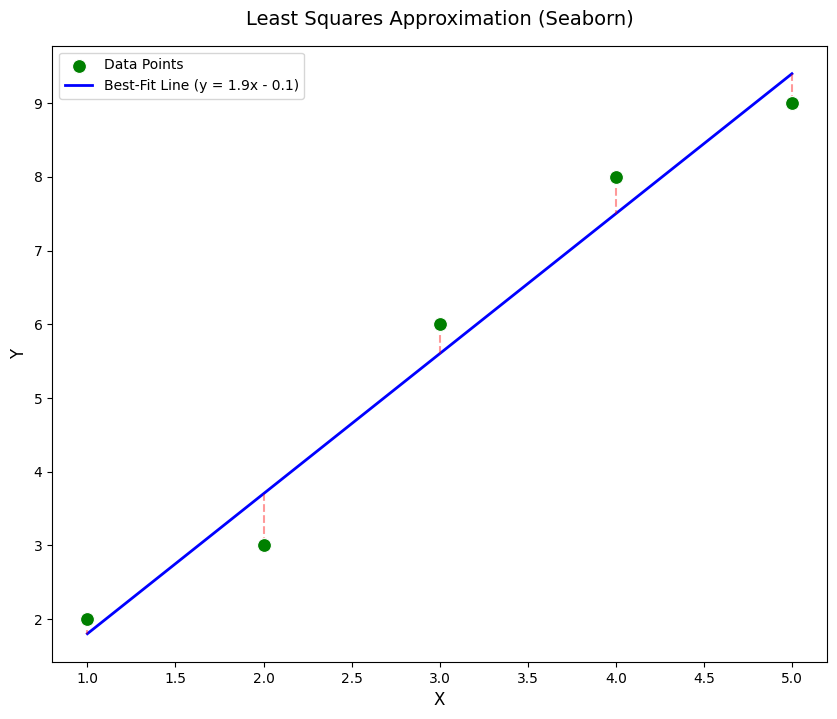

In [3]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=x, y=y, color='green', s=100, label='Data Points', zorder=5)
sns.lineplot(x=x, y=y_pred, color='blue', linewidth=2, label=f'Best-Fit Line (y = {m:.1f}x - {abs(c):.1f})')

for i in range(n):
    plt.vlines(x[i], y[i], y_pred[i], colors='red',linestyles='dashed', alpha=0.4)

plt.title('Least Squares Approximation (Seaborn)', fontsize=14, pad=15)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.legend(frameon=True)
plt.show()

# Q.2 Simulate the gradient descent algorithm for linear regression from scratch using random seed points.

In [4]:
#2. Simulate the gradient descent algorithm for linear regression from scratch using random seed points.


In [5]:
np.random.seed(42)
x_gd = np.array([1, 2, 3, 4, 5])
y_gd = np.array([2, 3, 6, 8, 9])

w = np.random.randn() #weight/slope
b = np.random.randn() #bias/intercept

learning_rate = 0.01
iterations = 1000
cost_history = []


### Gradient Descent Implementation

Here's the core of the gradient descent algorithm:

1.  **Prediction**: Calculate the predicted `y` values (`y_pred`) using the current `w` and `b`.
2.  **Cost Function**: Calculate the Mean Squared Error (MSE) to quantify how far off our predictions are.
3.  **Gradients**: Calculate the partial derivatives of the cost function with respect to `w` and `b`. These tell us the direction and magnitude to adjust `w` and `b`.
4.  **Update Parameters**: Adjust `w` and `b` in the direction opposite to their gradients, scaled by the `learning_rate`.
5.  **Iteration**: Repeat steps 1-4 for a specified number of `iterations`.

In [6]:
for i in range(iterations):
    y_pred_gd = w * x_gd + b #predicting y

    #calculate the Mean Squared Error means cost
    cost = (1/len(x_gd)) * np.sum((y_pred_gd - y_gd)**2)
    cost_history.append(cost)

    #calculate gradients
    dw = (2/len(x_gd)) * np.sum(x_gd * (y_pred_gd - y_gd))
    db = (2/len(x_gd)) * np.sum(y_pred_gd - y_gd)

    w = w - learning_rate * dw
    b = b - learning_rate * db

print(f"Final Weight (Slope): {w:.4f}")
print(f"Final Bias (Intercept): {b:.4f}")

#predictions with optimized parameters
y_final_pred_gd = w * x_gd + b


Final Weight (Slope): 1.8970
Final Bias (Intercept): -0.0890


### Visualization

Let's visualize the data points and the regression line learned by the gradient descent algorithm.

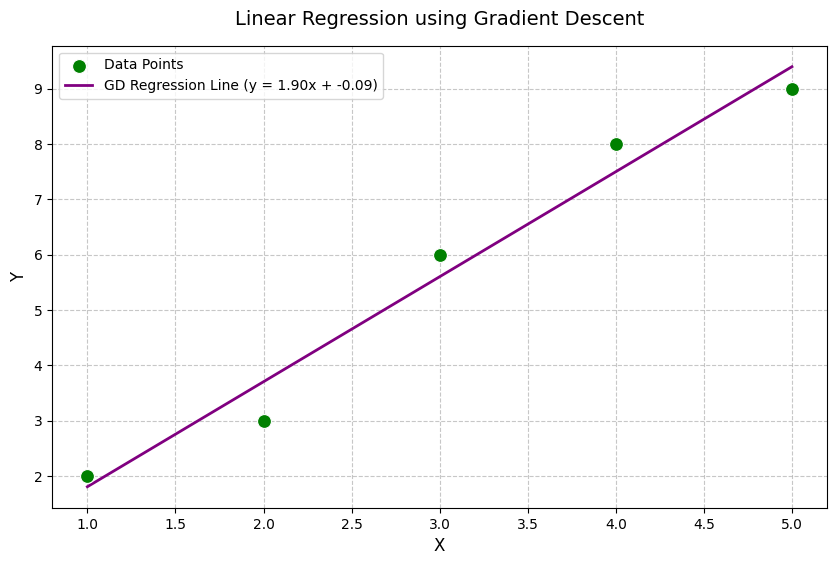

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_gd, y=y_gd, color='green', s=100, label='Data Points', zorder=5)
sns.lineplot(x=x_gd, y=y_final_pred_gd, color='purple', linewidth=2, label=f'GD Regression Line (y = {w:.2f}x + {b:.2f})')
plt.title('Linear Regression using Gradient Descent', fontsize=14, pad=15)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Cost History

plotting the cost history shows how the Mean Squared Error decreased over iterations, indicating that the model converged.

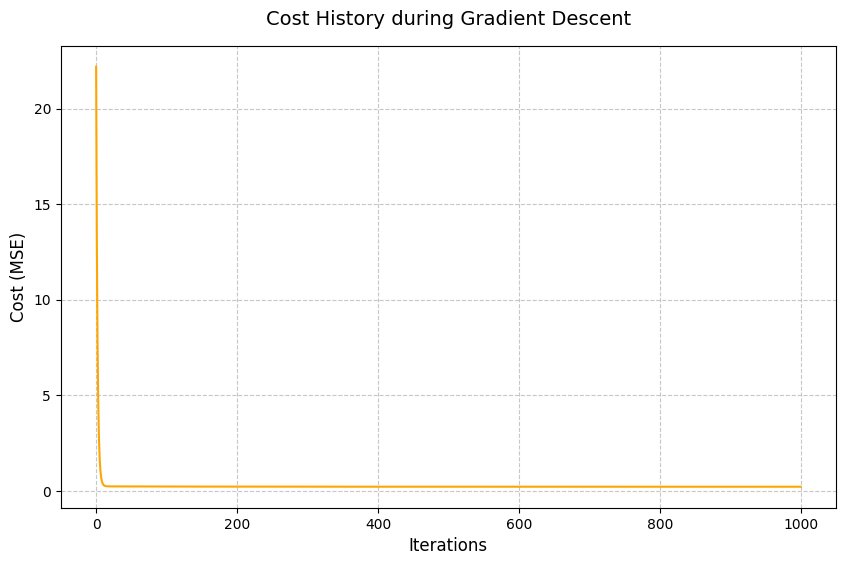

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), cost_history, color='orange')
plt.title('Cost History during Gradient Descent', fontsize=14, pad=15)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Q.3 Use titanic dataset, housing dataset from kaggle. Preprocess it for linear regression analysis and perform linear regression from scratch.

In [9]:
#3. Use titanic dataset, housing dataset from kaggle. Preprocess it for linear regression analysis and perform linear regression from scratch.

In [10]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
print("Dataframe Info:")
housing_df.info()

print("Missing values")
print(housing_df.isnull().sum())

X_housing = housing_df.drop('median_house_value', axis=1)
y_housing = housing_df['median_house_value']

#Splitting
X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

#Feature Scaling
scaler_housing = StandardScaler()
X_train_scaled_housing = scaler_housing.fit_transform(X_train_housing)
X_test_scaled_housing = scaler_housing.transform(X_test_housing)

#Adding bias to X
X_train_scaled_housing = np.c_[np.ones(X_train_scaled_housing.shape[0]), X_train_scaled_housing]
X_test_scaled_housing = np.c_[np.ones(X_test_scaled_housing.shape[0]), X_test_scaled_housing]

print(f"X_train_scaled_housing shape: {X_train_scaled_housing.shape}")
print(f"y_train_housing shape: {y_train_housing.shape}")

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
Missing values
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64
X_train_scaled_housing shape: (13600, 9)
y_train_hous

In [11]:
titanic_df = pd.read_csv('/content/tested.csv')
print("Dataframe Info:")
titanic_df.info()

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [12]:
print("Missing values")
print(titanic_df.isnull().sum())

Missing values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [13]:

titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median()) #Impute with the median
titanic_df['Fare'] =titanic_df['Fare'].fillna(titanic_df['Fare'].median()) #Impute with the median

print("Missing values after imputation:")
print(titanic_df.isnull().sum())


Missing values after imputation:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [14]:
#create hascabin; a binary feature tells the presence of a cabin
titanic_df['hascabin'] = titanic_df['Cabin'].apply(lambda x: 0 if pd.isnull(x) else 1)

# Drop Cabin column
titanic_df = titanic_df.drop('Cabin', axis=1)

print("\nUpdated Missing values after handling 'Cabin' column:")
print(titanic_df.isnull().sum())
display(titanic_df.head())


Updated Missing values after handling 'Cabin' column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
hascabin       0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,hascabin
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0


In [15]:
#One hot encoding
titanic_df = pd.get_dummies(titanic_df, columns=['Sex', 'Embarked'], drop_first=True) # drop_first to avoid multicollinearity

features_titanic = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X_titanic = titanic_df[features_titanic]
y_titanic = titanic_df['Survived'] # Target variable
print("DataFrame after feature engineering:")
display(X_titanic.head())


DataFrame after feature engineering:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,True,True,False
1,3,47.0,1,0,7.0000,False,False,True
2,2,62.0,0,0,9.6875,True,True,False
3,3,27.0,0,0,8.6625,True,False,True
4,3,22.0,1,1,12.2875,False,False,True


In [16]:
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

# Feature Scaling
scaler_titanic = StandardScaler()
X_train_scaled_titanic = scaler_titanic.fit_transform(X_train_titanic)
X_test_scaled_titanic = scaler_titanic.transform(X_test_titanic)

# Add a bias to X
X_train_scaled_titanic = np.c_[np.ones(X_train_scaled_titanic.shape[0]), X_train_scaled_titanic]
X_test_scaled_titanic = np.c_[np.ones(X_test_scaled_titanic.shape[0]), X_test_scaled_titanic]

print("\nTitanic Data Preprocessing Complete.")
print(f"X_train_scaled_titanic shape: {X_train_scaled_titanic.shape}")
print(f"y_train_titanic shape: {y_train_titanic.shape}")



Titanic Data Preprocessing Complete.
X_train_scaled_titanic shape: (334, 9)
y_train_titanic shape: (334,)
